<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/Regresi%C3%B3n1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
sns.set_theme(style="whitegrid")

In [10]:
try:
  dk= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/house-prices.csv")
  print("datros cargados", dk.shape)
except FileNotFoundError:
  print("no se encontro el archivo")

datros cargados (128, 8)


In [12]:
nulos= dk.isnull().sum()
print("valores nulos por columnas", nulos)

valores nulos por columnas Home            0
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64


In [13]:
dk.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [14]:
dk.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [15]:
dk.tail(5)

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West
127,128,124600,2250,3,3,4,No,North


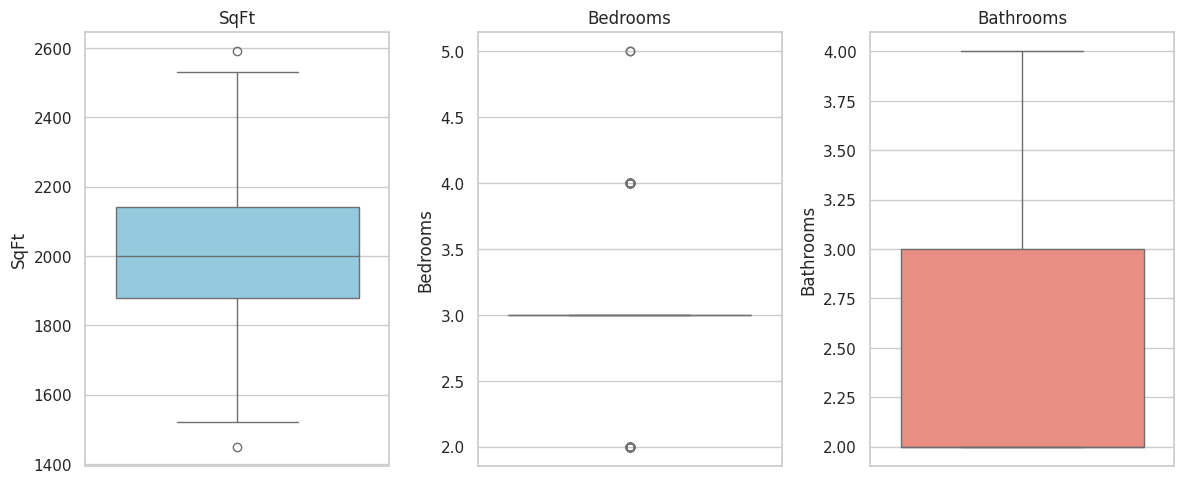

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(y=dk['SqFt'], color='skyblue').set_title('SqFt')
plt.subplot(1,3,2)
sns.boxplot(y=dk['Bedrooms'], color='lightgreen').set_title('Bedrooms')
plt.subplot(1,3,3)
sns.boxplot(y=dk['Bathrooms'], color='salmon').set_title('Bathrooms')
plt.tight_layout()
plt.show()


In [23]:
print("*************Preparacion de datos****************")
x= dk[['SqFt', 'Bedrooms', 'Bathrooms']]
y= dk['Price']

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)
print(f"SET entramiento: {x_train.shape[0]} registrados ")
print(f"SET prueba: {x_test.shape[0]} registros")

*************Preparacion de datos****************
SET entramiento: 102 registrados 
SET prueba: 26 registros


In [27]:
print("ENTRAMIENTO DEL MODELO")
modelo= LinearRegression()
modelo.fit(x_train, y_train)
print('Modelo entrenado con exito')
print("Coeficiente peso de cada variable", modelo.coef_)
print("Interaccion BIAS", modelo.intercept_)



ENTRAMIENTO DEL MODELO
Modelo entrenado con exito
Coeficiente peso de cada variable [   41.44755181 10278.00910207 13090.39118144]
Interaccion BIAS -16372.916362967444


In [31]:
print("EVALUCION DEL MODELO")
y_predi= modelo.predict(x_test)
mse= mean_squared_error(y_test, y_predi)
r2= r2_score(y_test, y_predi)

print(f"ERROR Cuadratico Medio: {mse:,.2f}")
print(f"R-cudrado: {r2:,.4f}")

EVALUCION DEL MODELO
ERROR Cuadratico Medio: 320,149,938.23
R-cudrado: 0.4568


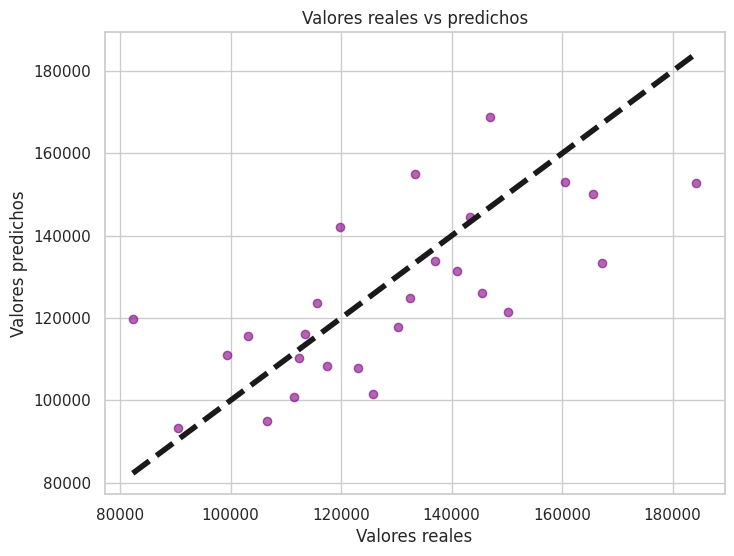

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_predi, alpha=0.6, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs predichos')
plt.show()

In [34]:
nuev_cas= pd.DataFrame([[2000, 3, 2]], columns=['SqFt', 'Bedrooms', 'Bathrooms'])
precio_esti= modelo.predict(nuev_cas)

print(f"Caracteristicas ingreesadas:: {nuev_cas.iloc[0].to_dict()}")
print(f"Precio de vent estimado: {precio_esti[0]:,.2f}")

Caracteristicas ingreesadas:: {'SqFt': 2000, 'Bedrooms': 3, 'Bathrooms': 2}
Precio de vent estimado: 123,537.00
